# EDA del dataset transformado `blast_observations.csv`

Este notebook realiza una **transformación previa del dataset** y luego ejecuta un **análisis exploratorio de datos (EDA)** sobre el conjunto transformado.

## Transformación aplicada

Se deja el dataset únicamente con estas variables:

```python
variables = [
    'BL_INFECTION', 'NDRE_MEAN', 'NDVI_MEAN', 'GNDVI_MEAN', 'BNDVI_MEAN',
    'NDREI_MEAN', 'NPCI_MEAN', 'GRVI_MEAN', 'NGBDI_MEAN'
]
```

Además, usando la misma columna `BL_INFECTION`, se crean dos columnas objetivo adicionales:

```python
mapa_2 = {1:1, 2:1, 3:1, 4:1, 5:1, 6:2, 7:2, 8:2, 9:2}
mapa_3 = {1:1, 2:1, 3:1, 4:1, 5:2, 6:2, 7:3, 8:3, 9:3}
```

In [2]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
plt.rcParams["figure.figsize"] = (12, 6)

CANDIDATE_PATHS = [
    Path("blast_observations.csv"),
    Path("C:\\Users\\RGUERRERO\\OneDrive - Universidad Autonoma de Occidente\\MAESTRIA IA&CD\\ETL\\ETL - PROYECTO COMPARTIDO\\DATASET FINAL\\blast_observations.csv"),
]

DATA_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró el archivo blast_observations.csv. "
        "Coloca el CSV en la misma carpeta del notebook o ajusta la ruta."
    )

print(f"Usando dataset: {DATA_PATH.resolve()}")


Usando dataset: C:\Users\RGUERRERO\OneDrive - Universidad Autonoma de Occidente\MAESTRIA IA&CD\ETL\ETL - PROYECTO COMPARTIDO\DATASET FINAL\blast_observations.csv


## 1. Carga y transformación del dataset

In [3]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)

for col in raw_df.select_dtypes(include="object").columns:
    raw_df[col] = raw_df[col].astype("string").str.strip()

if "BL_INFECTION" not in raw_df.columns:
    raise KeyError("La columna 'BL_INFECTION' no existe en el dataset original.")

variables = [
    "BL_INFECTION", "NDRE_MEAN", "NDVI_MEAN", "GNDVI_MEAN", "BNDVI_MEAN",
    "NDREI_MEAN", "NPCI_MEAN", "GRVI_MEAN", "NGBDI_MEAN"
]

faltantes = [col for col in variables if col not in raw_df.columns]
if faltantes:
    raise KeyError(f"Faltan columnas requeridas en el dataset: {faltantes}")

columna = "BL_INFECTION"

mapa_2 = {1:1, 2:1, 3:1, 4:1, 5:1, 6:2, 7:2, 8:2, 9:2}
mapa_3 = {1:1, 2:1, 3:1, 4:1, 5:2, 6:2, 7:3, 8:3, 9:3}

df = raw_df[variables].copy()
df["BL_2_CLASS"] = df[columna].replace(mapa_2)
df["BL_3_CLASS"] = df[columna].replace(mapa_3)

print(f"Dataset original: {raw_df.shape[0]:,} filas x {raw_df.shape[1]:,} columnas")
print(f"Dataset transformado: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
display(df.head())

output_path = "blast_observations_transformado.csv"
df.to_csv(output_path, index=False)
print(f"Dataset transformado guardado en: {output_path}")


Dataset original: 318,353 filas x 95 columnas
Dataset transformado: 318,353 filas x 11 columnas


,BL_INFECTION,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN,BL_2_CLASS,BL_3_CLASS
0,6.0,-0.063189,0.310896,-0.002796,0.107131,0.368609,0.169279,0.323468,0.112283,2.0,2.0
1,6.0,-0.057977,0.323658,0.003995,0.118224,0.377074,0.175103,0.333351,0.117037,2.0,2.0
2,6.0,-0.060040,0.365067,0.070052,0.161457,0.419151,0.220194,0.316903,0.095609,2.0,2.0
3,6.0,-0.060797,0.346153,0.053861,0.153853,0.401472,0.213218,0.312402,0.104020,2.0,2.0
4,6.0,-0.054292,0.351395,0.026765,0.186943,0.400630,0.239586,0.339164,0.164446,2.0,2.0


Dataset transformado guardado en: blast_observations_transformado.csv


## 2. Resumen estructural

In [4]:

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

summary_table = pd.DataFrame({
    "métrica": [
        "n_filas",
        "n_columnas",
        "n_columnas_numéricas",
        "n_columnas_no_numéricas",
        "memoria_MB",
    ],
    "valor": [
        df.shape[0],
        df.shape[1],
        len(numeric_cols),
        len(categorical_cols),
        round(df.memory_usage(deep=True).sum() / 1024**2, 2),
    ]
})

display(summary_table)
display(pd.DataFrame({"columna": df.columns, "dtype": df.dtypes.astype(str).values}))


,métrica,valor
0,n_filas,318353.00
1,n_columnas,11.00
2,n_columnas_numéricas,11.00
3,n_columnas_no_numéricas,0.00
4,memoria_MB,26.72


,columna,dtype
0,BL_INFECTION,float64
1,NDRE_MEAN,float64
2,NDVI_MEAN,float64
3,GNDVI_MEAN,float64
4,BNDVI_MEAN,float64
5,NDREI_MEAN,float64
6,NPCI_MEAN,float64
7,GRVI_MEAN,float64
8,NGBDI_MEAN,float64
9,BL_2_CLASS,float64


## 3. Calidad de datos

In [5]:

missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename("missing_pct")
      .to_frame()
)

duplicates = pd.DataFrame({
    "duplicados_exactos": [int(df.duplicated().sum())],
    "porcentaje_duplicados": [round(df.duplicated().mean() * 100, 2)]
})

print("Porcentaje de nulos por columna:")
display(missing)

print("Duplicados exactos:")
display(duplicates)

print("Cantidad de valores únicos por columna:")
display(df.nunique(dropna=False).rename("n_unicos").to_frame())


Porcentaje de nulos por columna:


,missing_pct
BL_INFECTION,14.542976
BL_2_CLASS,14.542976
BL_3_CLASS,14.542976
NDRE_MEAN,0.085754
NDVI_MEAN,0.085754
GNDVI_MEAN,0.085754
BNDVI_MEAN,0.085754
NDREI_MEAN,0.085754
NPCI_MEAN,0.085754
GRVI_MEAN,0.085754


Duplicados exactos:


,duplicados_exactos,porcentaje_duplicados
0,94043,29.54


Cantidad de valores únicos por columna:


,n_unicos
BL_INFECTION,10
NDRE_MEAN,217889
NDVI_MEAN,213232
GNDVI_MEAN,214730
BNDVI_MEAN,214200
NDREI_MEAN,212975
NPCI_MEAN,213412
GRVI_MEAN,216752
NGBDI_MEAN,217495
BL_2_CLASS,3


## 4. Estadísticos descriptivos

In [6]:

desc = df[numeric_cols].describe().T
desc["missing_pct"] = df[numeric_cols].isna().mean() * 100
desc["skew"] = df[numeric_cols].skew(numeric_only=True)
desc["kurtosis"] = df[numeric_cols].kurtosis(numeric_only=True)
display(desc.sort_index())


,count,mean,std,min,25%,50%,75%,max,missing_pct,skew,kurtosis
BL_2_CLASS,272055.0,1.104699,0.306166,1.000000,1.000000,1.000000,1.000000,2.000000,14.542976,2.582280,4.668203
BL_3_CLASS,272055.0,1.228649,0.515893,1.000000,1.000000,1.000000,1.000000,3.000000,14.542976,2.210196,3.964632
BL_INFECTION,272055.0,3.122898,1.691679,1.000000,2.000000,3.000000,4.000000,9.000000,14.542976,0.820189,0.473108
BNDVI_MEAN,318080.0,0.799279,0.191341,-0.228165,0.773984,0.851474,0.902147,0.964221,0.085754,-3.249266,10.736703
GNDVI_MEAN,318080.0,0.673825,0.171668,-0.304843,0.637831,0.711350,0.767726,0.890298,0.085754,-3.047203,10.434207
GRVI_MEAN,318080.0,0.413191,0.088278,-0.192741,0.362712,0.416031,0.478431,0.748969,0.085754,-0.620722,1.015596
NDREI_MEAN,318080.0,0.693036,0.115473,-0.114615,0.665918,0.717677,0.757470,0.896975,0.085754,-2.828804,9.371476
NDRE_MEAN,318080.0,0.388260,0.166292,-0.203660,0.277915,0.394105,0.527510,0.735638,0.085754,-0.622639,0.266616
NDVI_MEAN,318080.0,0.826552,0.152609,-0.105971,0.807298,0.864042,0.905586,0.975277,0.085754,-3.388766,12.240379
NGBDI_MEAN,318080.0,0.337355,0.163366,-0.232827,0.157420,0.424335,0.461056,0.615567,0.085754,-0.764953,-0.883060


## 5. Distribuciones univariadas

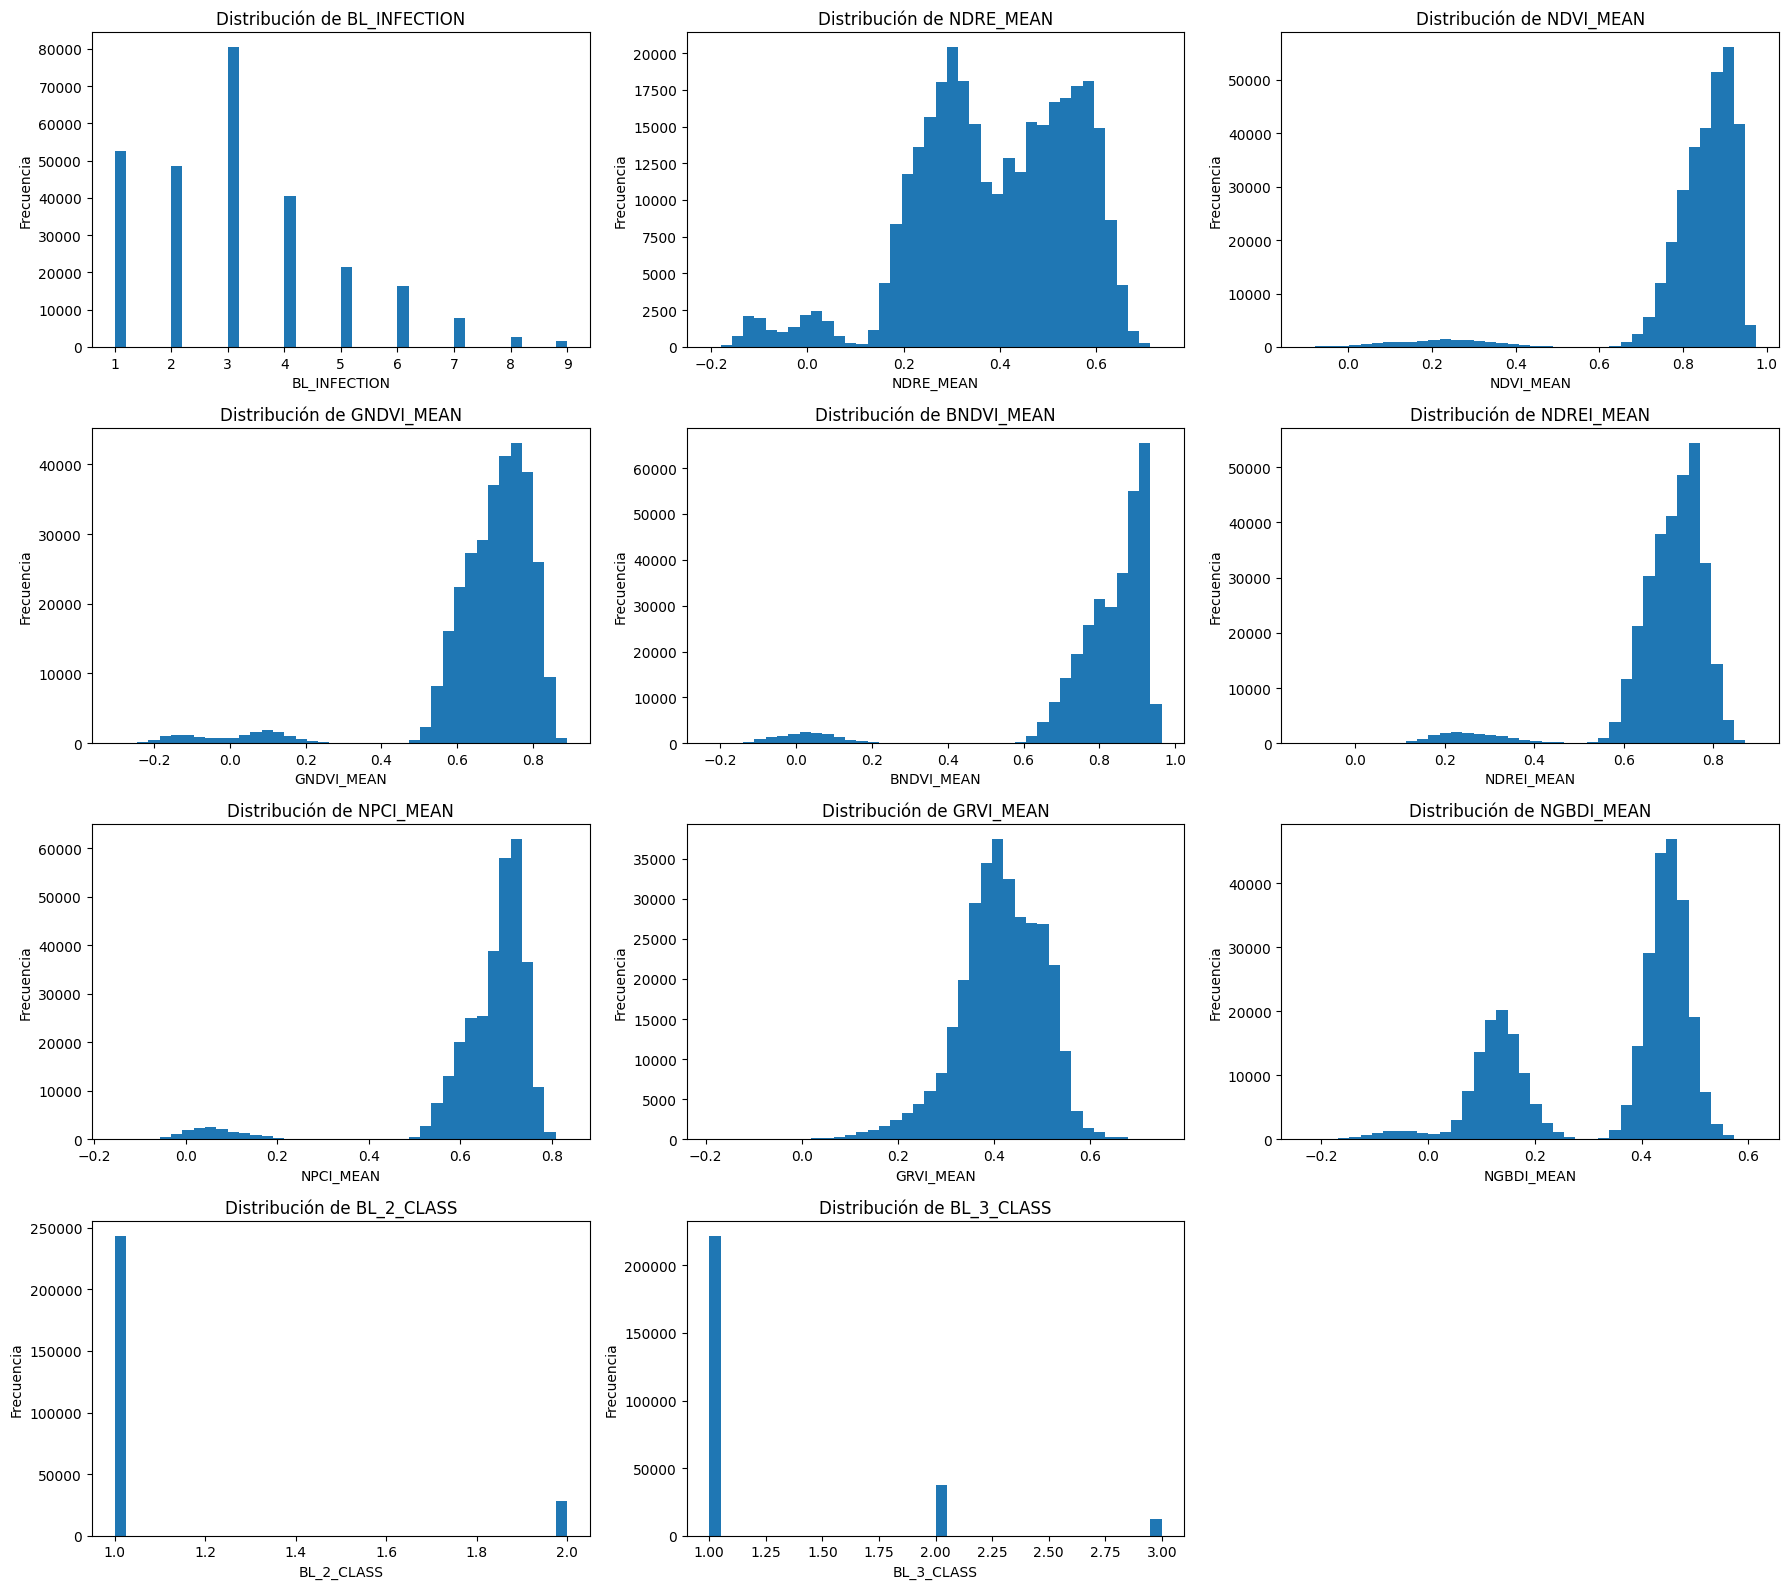

In [7]:

feature_cols = [
    "BL_INFECTION", "NDRE_MEAN", "NDVI_MEAN", "GNDVI_MEAN", "BNDVI_MEAN",
    "NDREI_MEAN", "NPCI_MEAN", "GRVI_MEAN", "NGBDI_MEAN",
    "BL_2_CLASS", "BL_3_CLASS"
]

n = len(feature_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, feature_cols):
    series = df[col].dropna()
    ax.hist(series, bins=40)
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 6. Outliers y dispersión

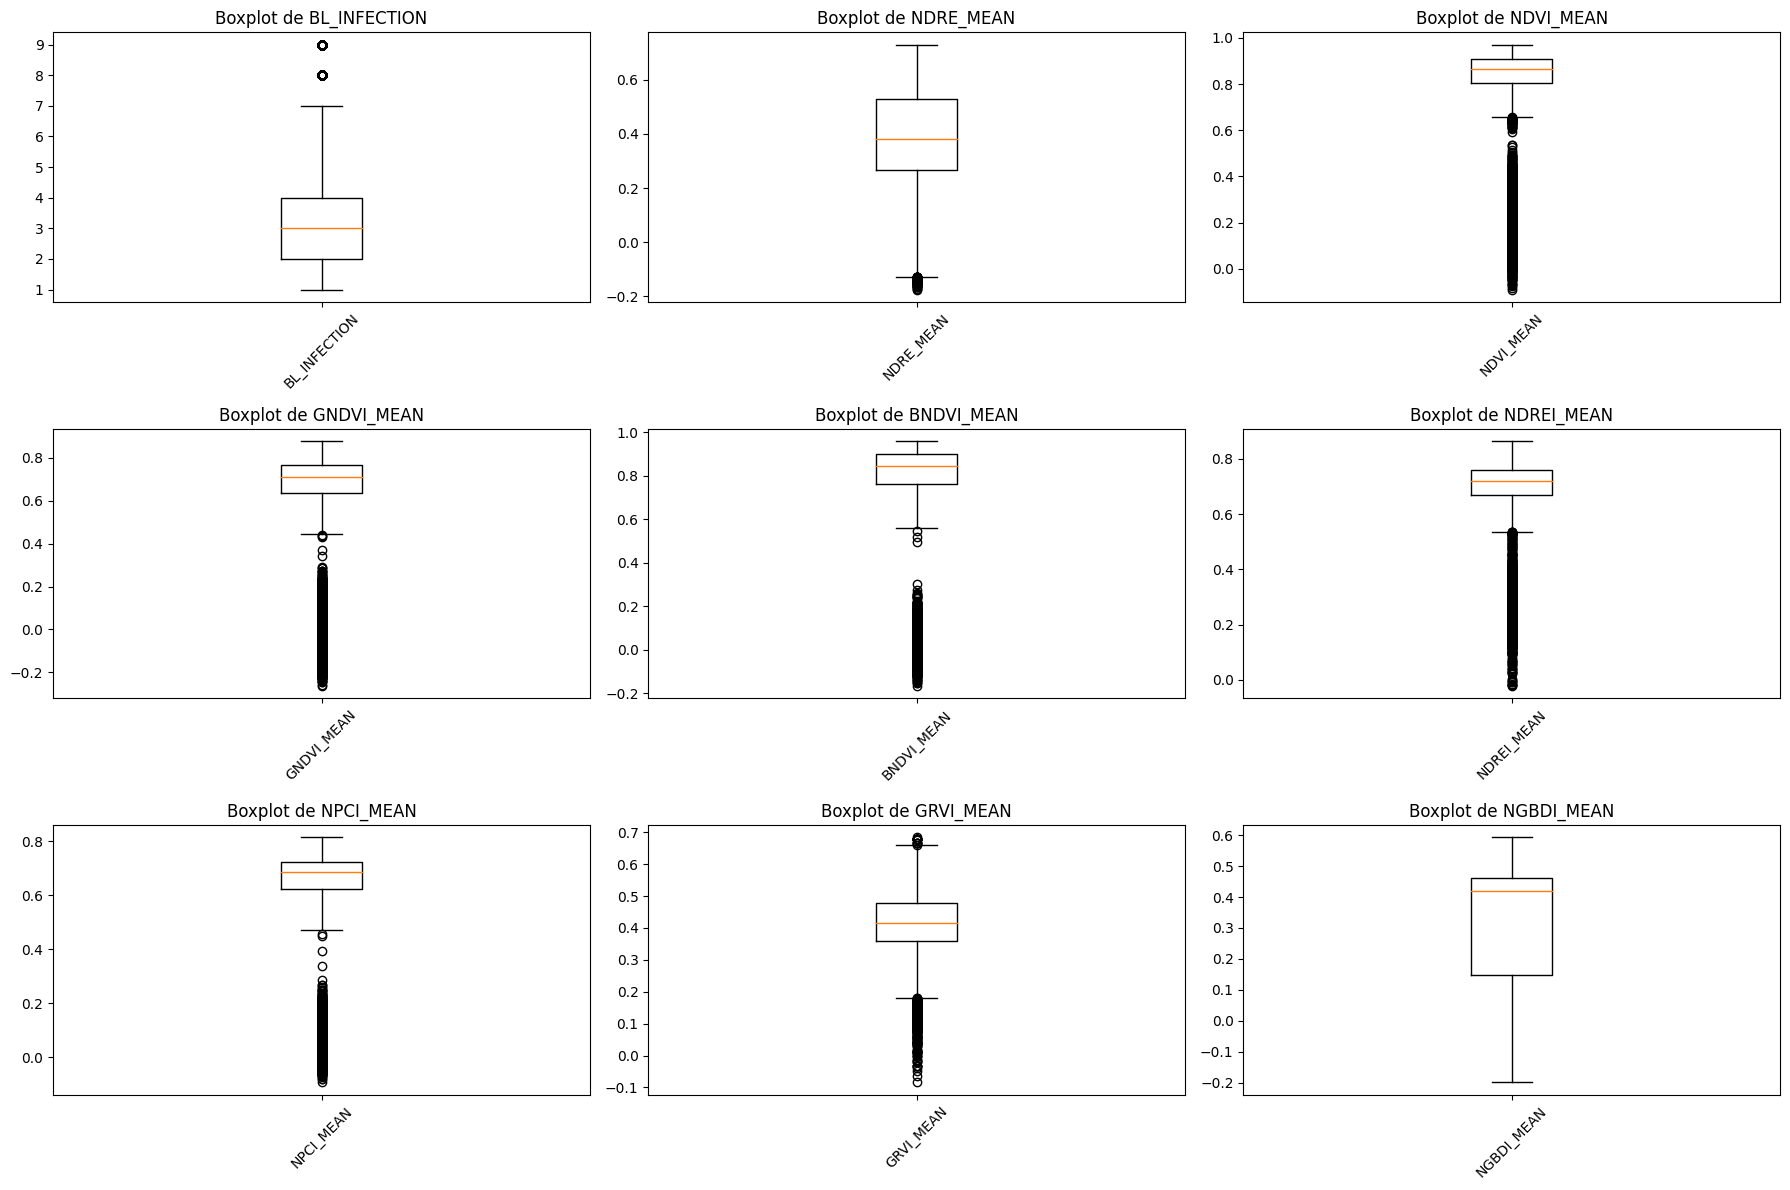

In [8]:

boxplot_cols = [c for c in feature_cols if c not in ["BL_2_CLASS", "BL_3_CLASS"]]

sample_df = df[boxplot_cols].dropna()
if len(sample_df) > 30000:
    sample_df = sample_df.sample(30000, random_state=42)

n = len(boxplot_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, boxplot_cols):
    ax.boxplot(sample_df[col].dropna(), vert=True)
    ax.set_title(f"Boxplot de {col}")
    ax.set_xticks([1])
    ax.set_xticklabels([col], rotation=45)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 7. Correlaciones

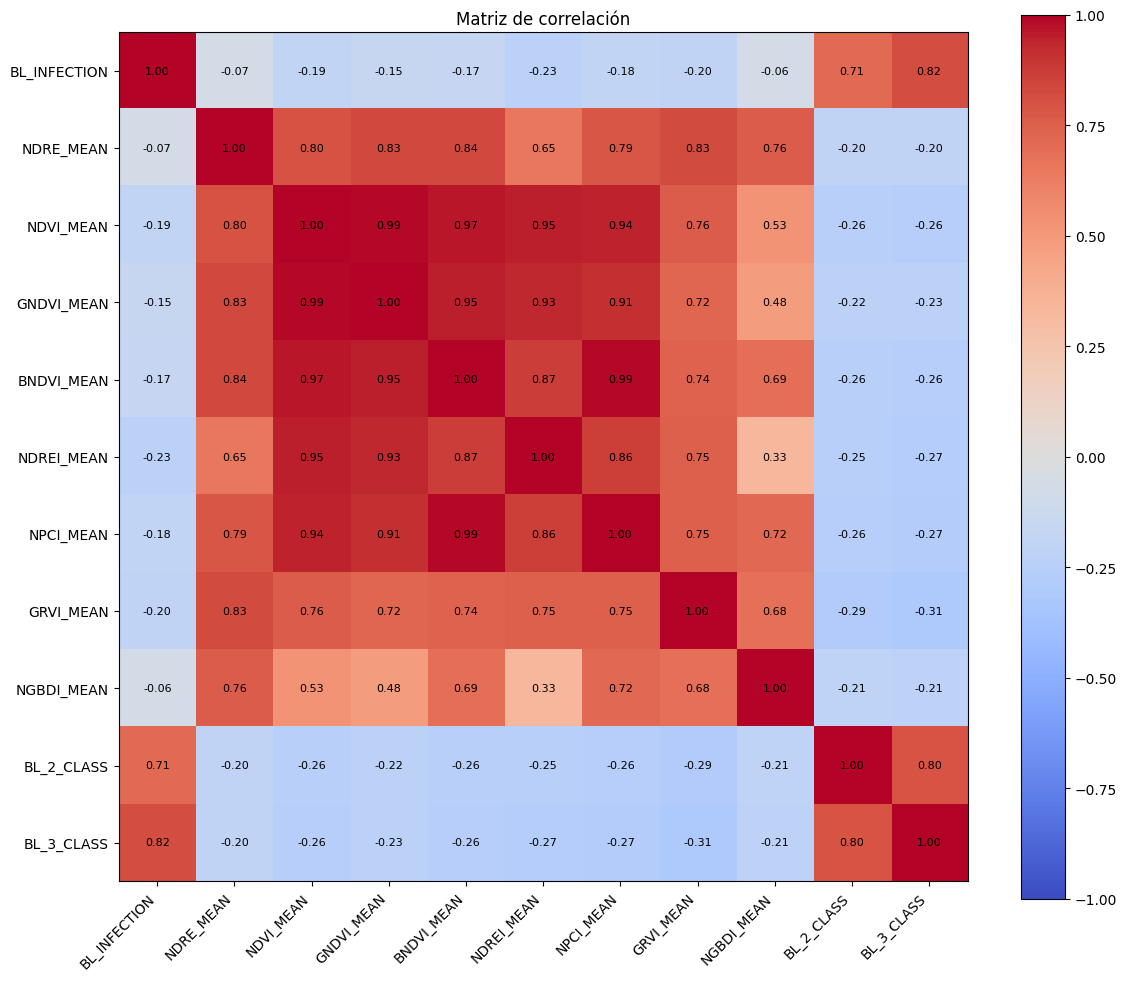

,BL_INFECTION,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN,BL_2_CLASS,BL_3_CLASS
BL_INFECTION,1.000,-0.066,-0.192,-0.155,-0.171,-0.230,-0.184,-0.198,-0.064,0.710,0.815
NDRE_MEAN,-0.066,1.000,0.802,0.829,0.836,0.654,0.786,0.826,0.763,-0.201,-0.202
NDVI_MEAN,-0.192,0.802,1.000,0.986,0.968,0.953,0.941,0.758,0.526,-0.257,-0.265
GNDVI_MEAN,-0.155,0.829,0.986,1.000,0.948,0.931,0.907,0.721,0.484,-0.222,-0.227
BNDVI_MEAN,-0.171,0.836,0.968,0.948,1.000,0.869,0.987,0.742,0.688,-0.257,-0.263
NDREI_MEAN,-0.230,0.654,0.953,0.931,0.869,1.000,0.860,0.747,0.334,-0.255,-0.269
NPCI_MEAN,-0.184,0.786,0.941,0.907,0.987,0.860,1.000,0.748,0.717,-0.265,-0.274
GRVI_MEAN,-0.198,0.826,0.758,0.721,0.742,0.747,0.748,1.000,0.684,-0.288,-0.307
NGBDI_MEAN,-0.064,0.763,0.526,0.484,0.688,0.334,0.717,0.684,1.000,-0.211,-0.213
BL_2_CLASS,0.710,-0.201,-0.257,-0.222,-0.257,-0.255,-0.265,-0.288,-0.211,1.000,0.796


In [9]:

corr_matrix = df[feature_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

display(corr_matrix.round(3))


## 8. Balance de clases


Distribución de clases en BL_INFECTION:


,conteo,porcentaje
BL_INFECTION,,
1.0,52504,16.49
2.0,48569,15.26
3.0,80510,25.29
4.0,40479,12.72
5.0,21509,6.76
6.0,16272,5.11
7.0,7895,2.48
8.0,2783,0.87
9.0,1534,0.48


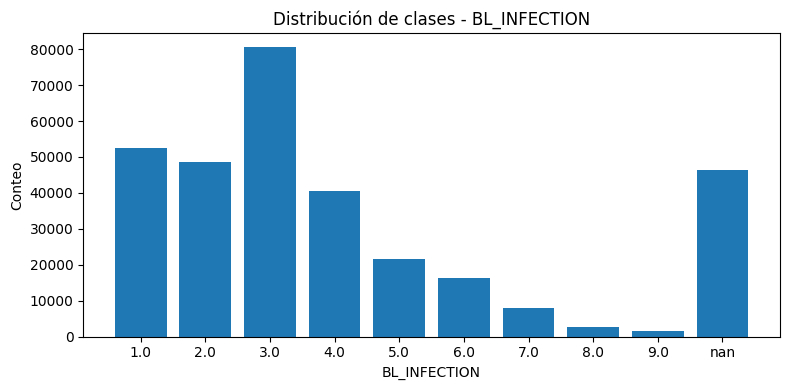


Distribución de clases en BL_2_CLASS:


,conteo,porcentaje
BL_2_CLASS,,
1.0,243571,76.51
2.0,28484,8.95
NaN,46298,14.54


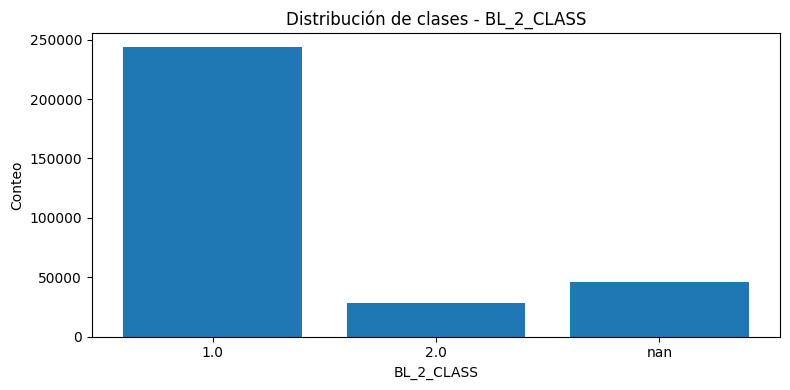


Distribución de clases en BL_3_CLASS:


,conteo,porcentaje
BL_3_CLASS,,
1.0,222062,69.75
2.0,37781,11.87
3.0,12212,3.84
NaN,46298,14.54


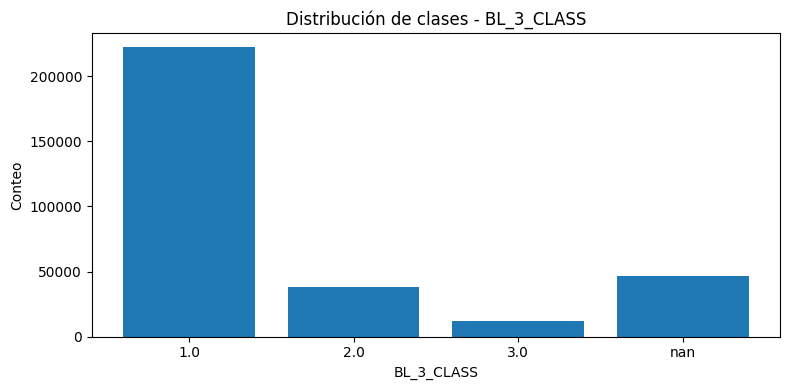

In [10]:

for target_col in ["BL_INFECTION", "BL_2_CLASS", "BL_3_CLASS"]:
    counts = df[target_col].value_counts(dropna=False).sort_index()
    proportions = df[target_col].value_counts(dropna=False, normalize=True).sort_index().mul(100)

    balance = pd.DataFrame({
        "conteo": counts,
        "porcentaje": proportions.round(2)
    })

    print(f"\nDistribución de clases en {target_col}:")
    display(balance)

    plt.figure(figsize=(8, 4))
    plt.bar(balance.index.astype(str), balance["conteo"])
    plt.title(f"Distribución de clases - {target_col}")
    plt.xlabel(target_col)
    plt.ylabel("Conteo")
    plt.tight_layout()
    plt.show()


## 9. Relación de variables espectrales con las clases


Promedio de variables por clase en BL_INFECTION:


,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN
BL_INFECTION,,,,,,,,
1.0,0.3359,0.8266,0.6702,0.7725,0.7142,0.6303,0.4078,0.2564
2.0,0.3795,0.8286,0.6695,0.8087,0.6929,0.6603,0.4129,0.3525
3.0,0.4251,0.8522,0.6995,0.8354,0.7081,0.6779,0.4347,0.3788
4.0,0.4281,0.8420,0.6944,0.8160,0.7013,0.6599,0.4314,0.3605
5.0,0.3669,0.8031,0.6516,0.7638,0.6776,0.6215,0.3980,0.3053
6.0,0.3087,0.7404,0.5882,0.6822,0.6382,0.5604,0.3663,0.2452
7.0,0.2486,0.6413,0.4915,0.5681,0.5519,0.4688,0.3107,0.2041
8.0,0.2247,0.6415,0.5093,0.5739,0.5405,0.4652,0.2546,0.1593
9.0,0.2216,0.6687,0.5259,0.6090,0.5651,0.4960,0.2680,0.1725



Promedio de variables por clase en BL_2_CLASS:


,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN
BL_2_CLASS,,,,,,,,
1.0,0.3922,0.8359,0.6821,0.8070,0.7026,0.6562,0.4208,0.3377
2.0,0.2792,0.6994,0.5503,0.6361,0.6009,0.5223,0.3348,0.2216



Promedio de variables por clase en BL_3_CLASS:


,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN
BL_3_CLASS,,,,,,,,
1.0,0.3946,0.8391,0.6851,0.8112,0.7050,0.6595,0.4230,0.3408
2.0,0.3418,0.7761,0.6243,0.7286,0.6606,0.5951,0.3843,0.2794
3.0,0.2398,0.6448,0.4998,0.5745,0.5509,0.4714,0.2926,0.1900


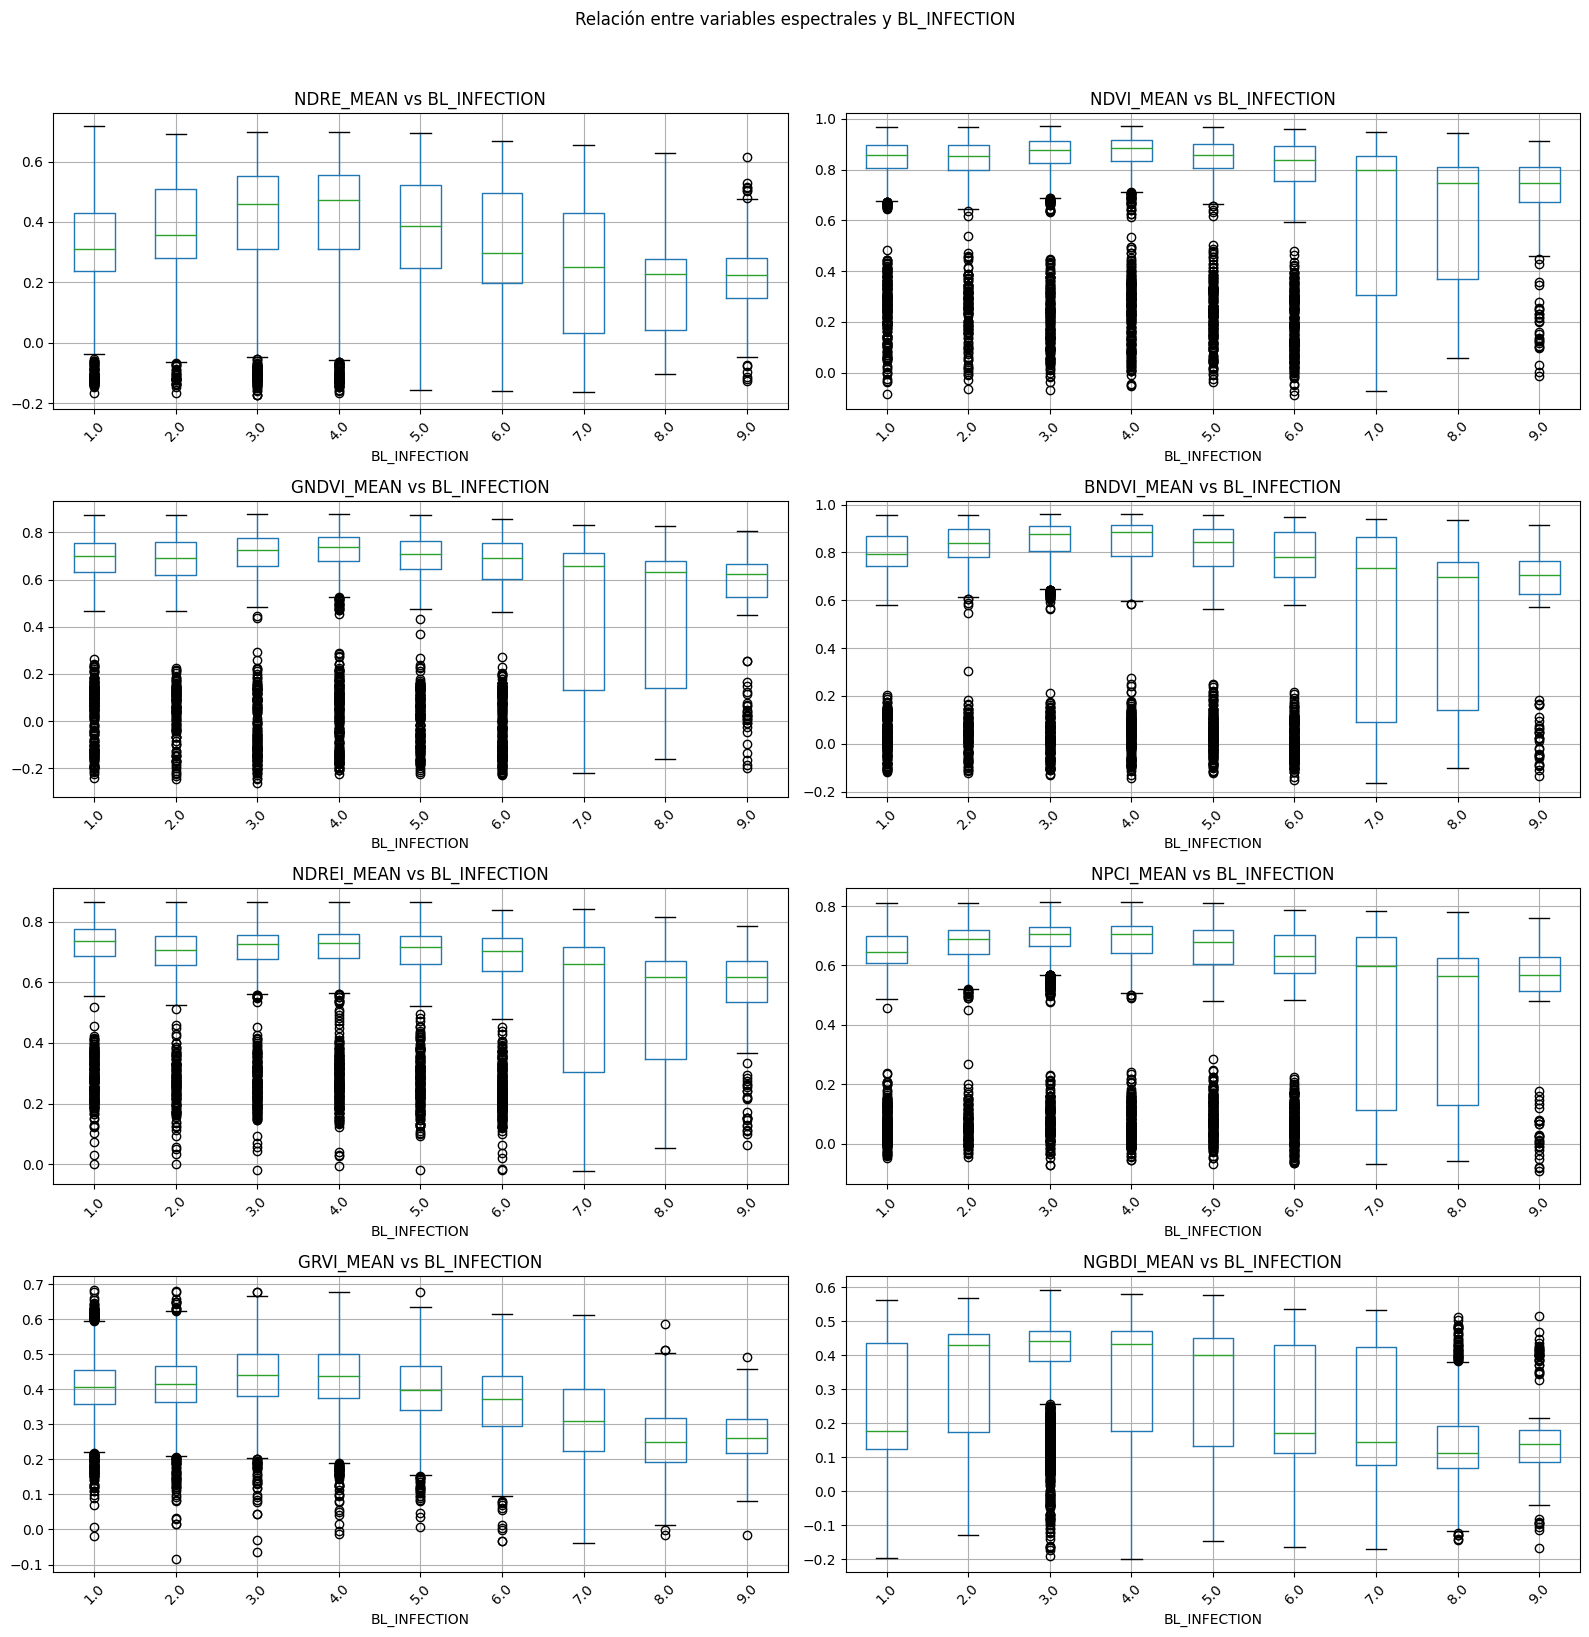

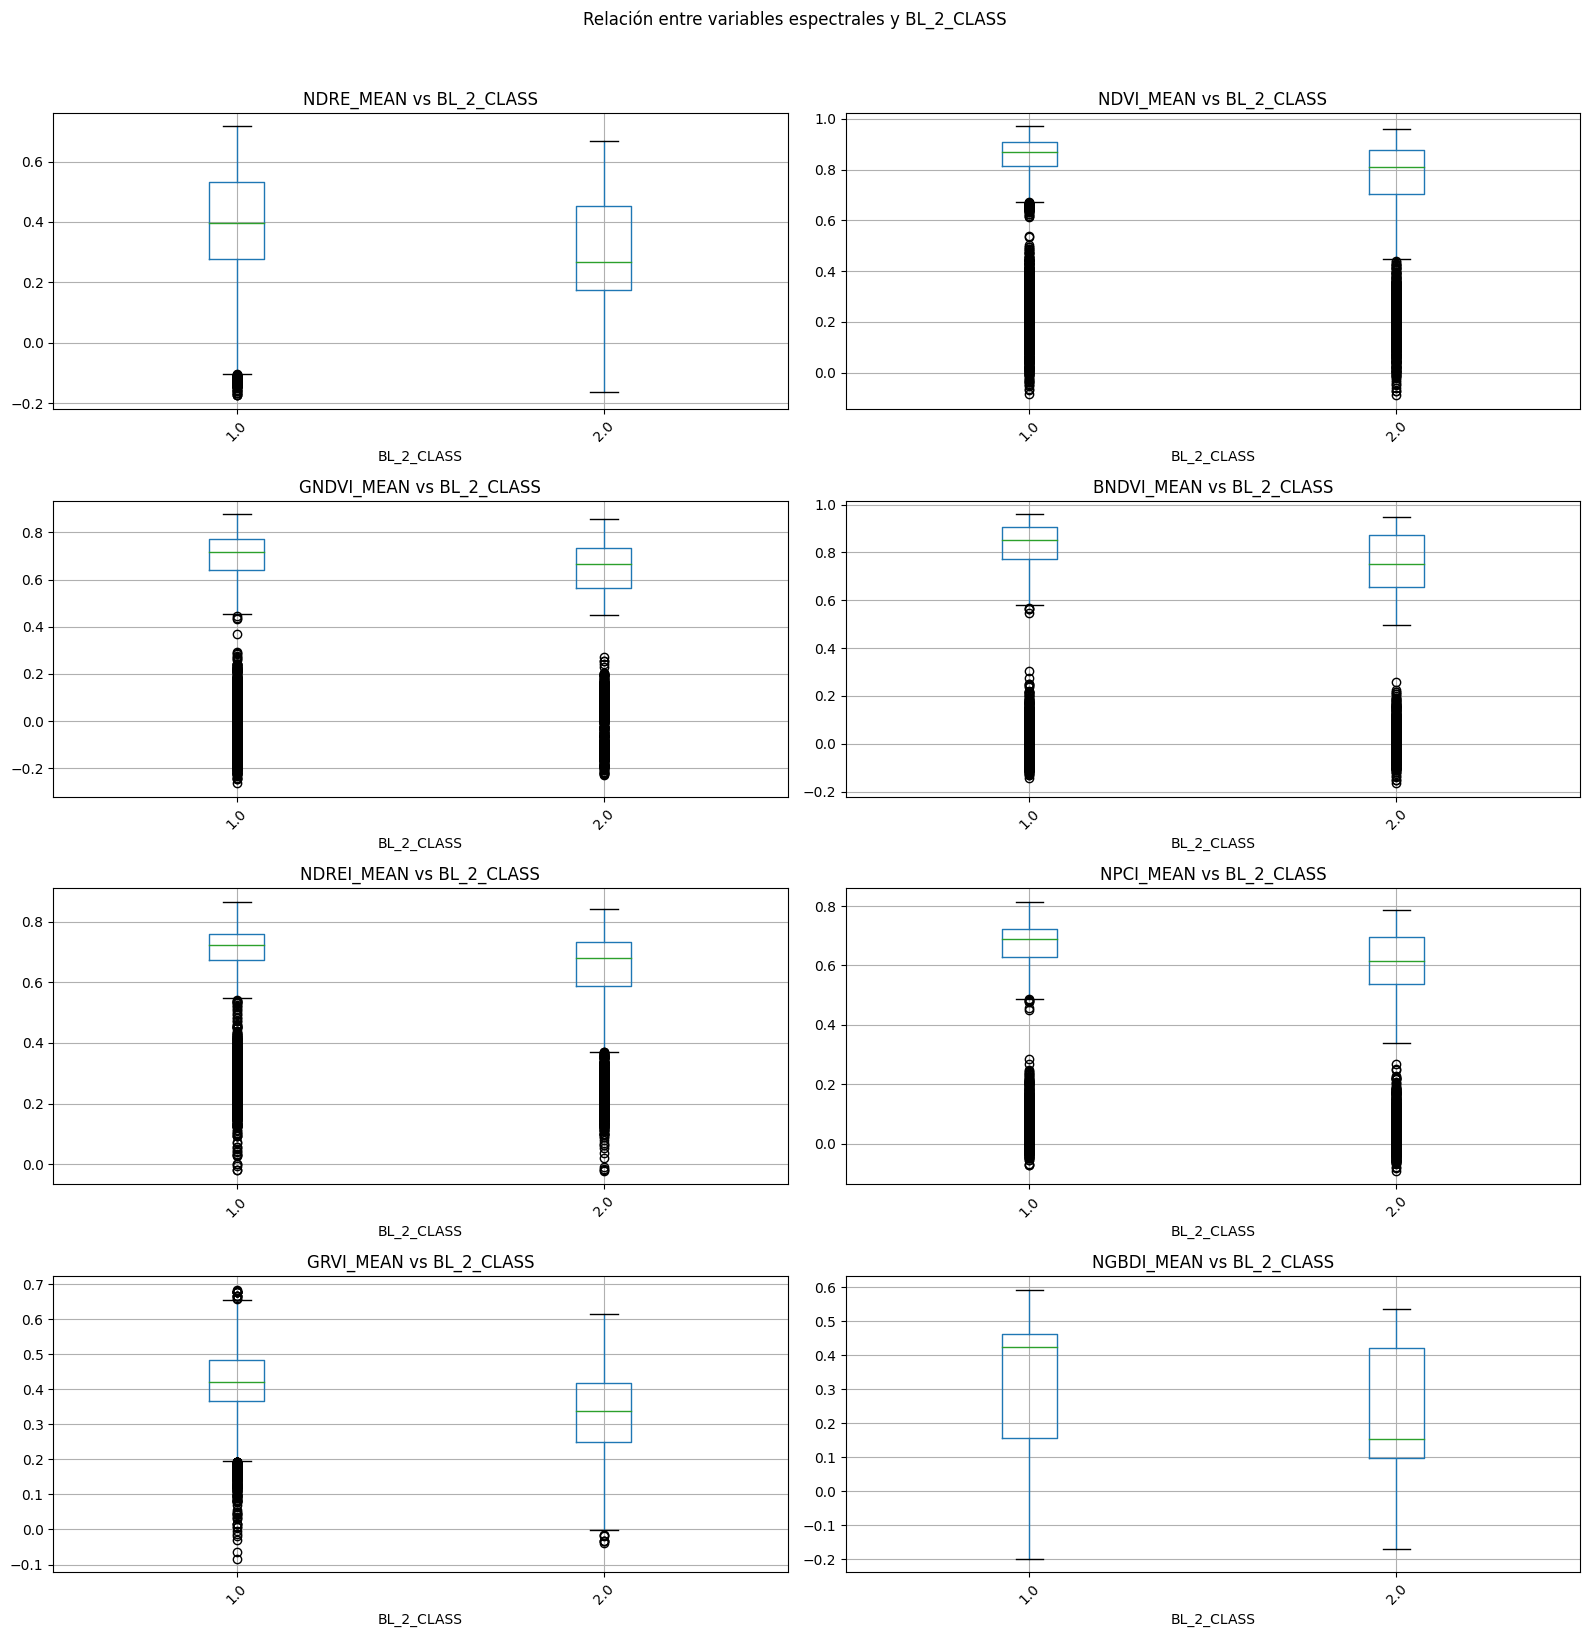

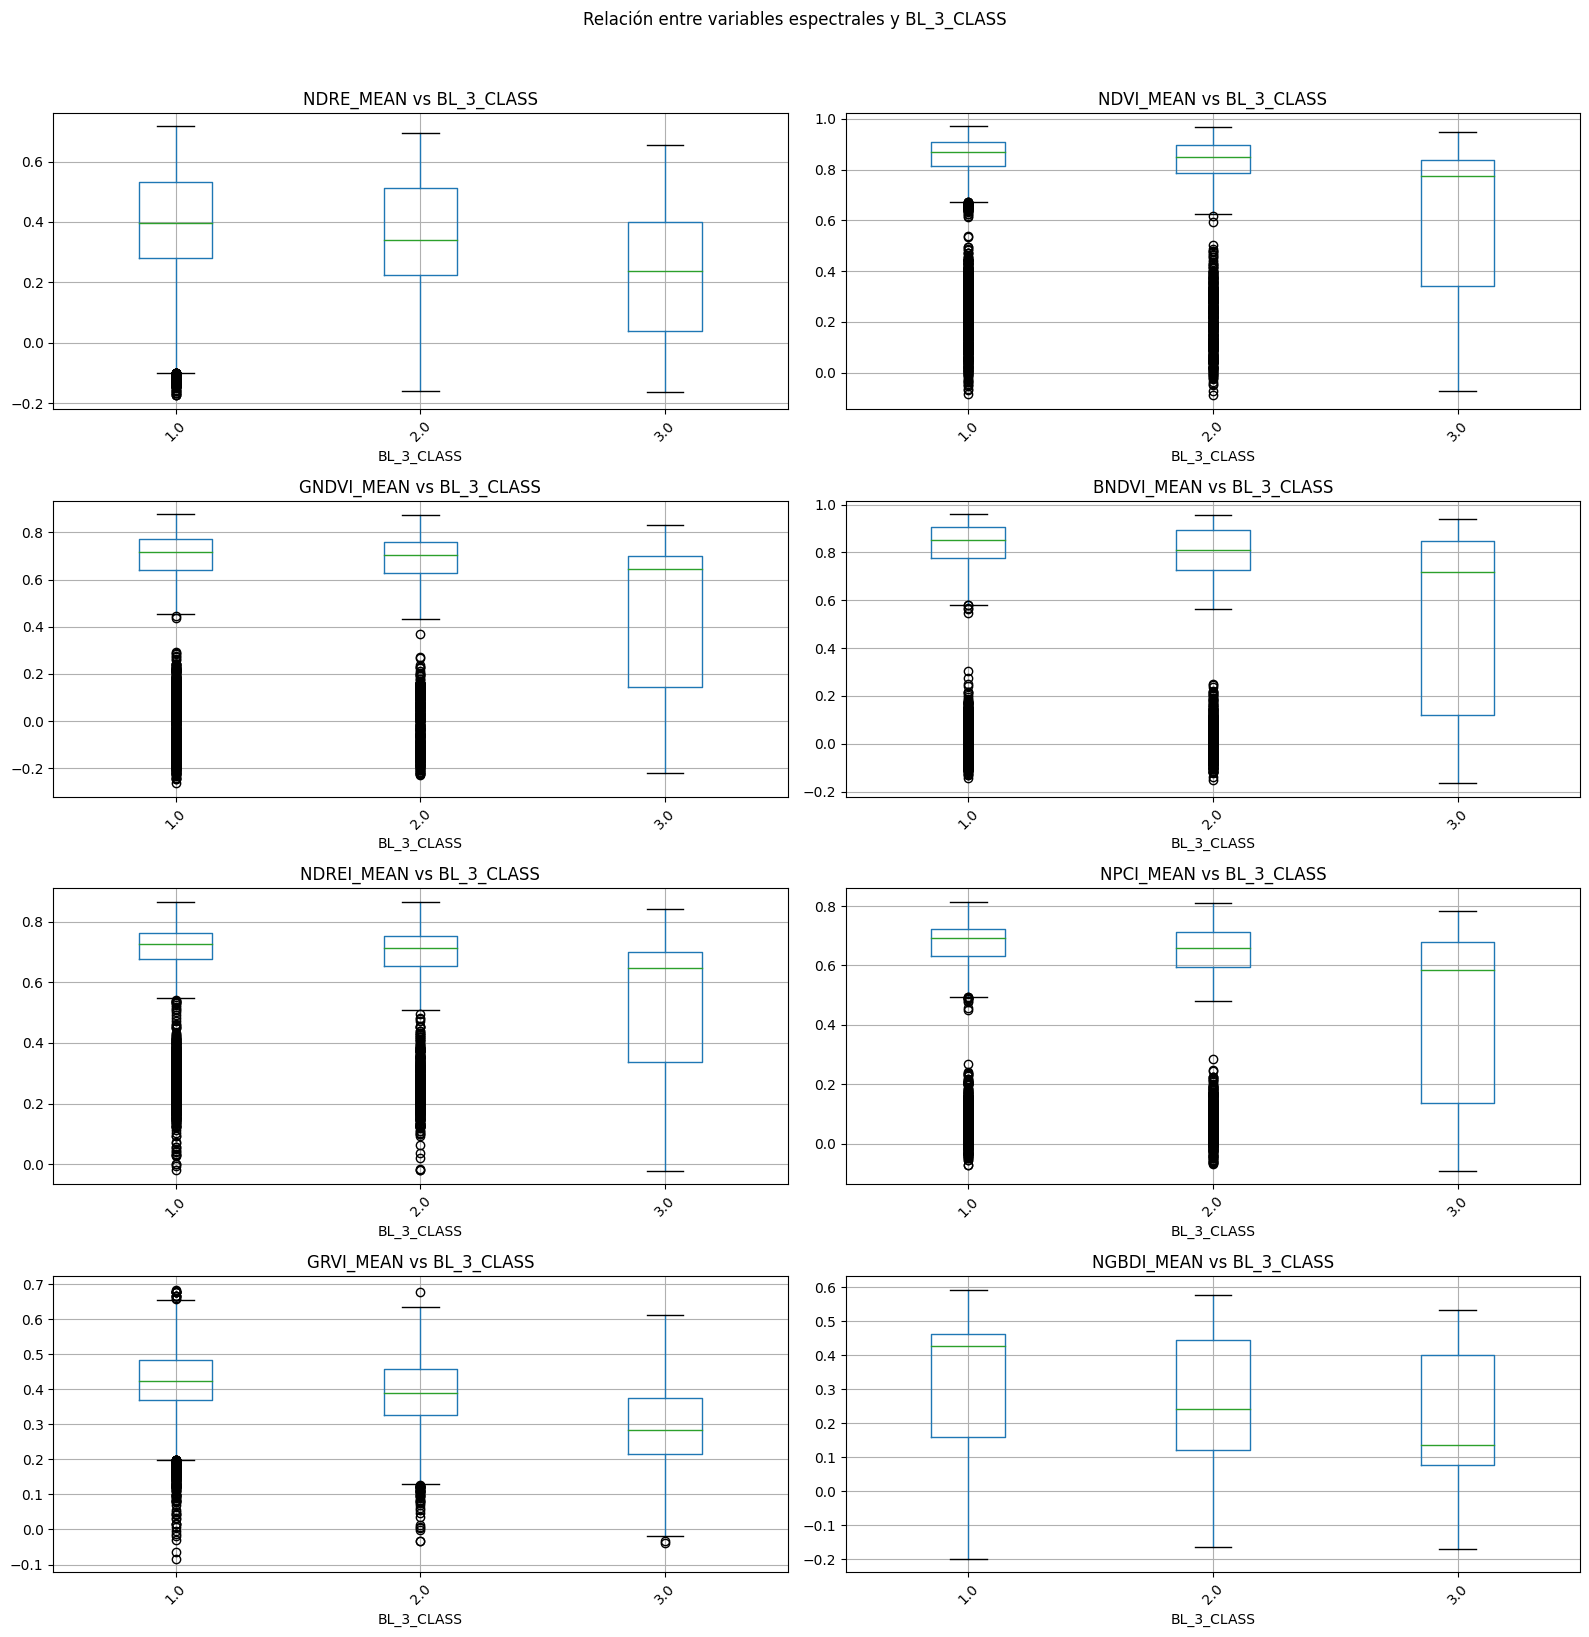

In [11]:

spectral_cols = [
    "NDRE_MEAN", "NDVI_MEAN", "GNDVI_MEAN", "BNDVI_MEAN",
    "NDREI_MEAN", "NPCI_MEAN", "GRVI_MEAN", "NGBDI_MEAN"
]

for target_col in ["BL_INFECTION", "BL_2_CLASS", "BL_3_CLASS"]:
    mean_by_class = df.groupby(target_col)[spectral_cols].mean().round(4)
    print(f"\nPromedio de variables por clase en {target_col}:")
    display(mean_by_class)

sample_rel = df[[*spectral_cols, "BL_INFECTION", "BL_2_CLASS", "BL_3_CLASS"]].dropna()
if len(sample_rel) > 25000:
    sample_rel = sample_rel.sample(25000, random_state=42)

for target_col in ["BL_INFECTION", "BL_2_CLASS", "BL_3_CLASS"]:
    n = len(spectral_cols)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, spectral_cols):
        sample_rel.boxplot(column=col, by=target_col, ax=ax)
        ax.set_title(f"{col} vs {target_col}")
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(f"Relación entre variables espectrales y {target_col}", y=1.02)
    plt.tight_layout()
    plt.show()


## 10. Hallazgos automáticos

In [12]:

findings = []

findings.append(f"- El dataset transformado contiene **{len(df):,} filas** y **{df.shape[1]} columnas**.")
findings.append(
    f"- Se detectaron **{int(df.duplicated().sum()):,} duplicados exactos**, equivalentes al **{df.duplicated().mean() * 100:.2f}%** del total."
)

top_missing = df.isna().mean().sort_values(ascending=False).head(5)
for col, pct in top_missing.items():
    findings.append(f"- La columna **{col}** tiene **{pct * 100:.2f}%** de valores nulos.")

for class_col in ["BL_INFECTION", "BL_2_CLASS", "BL_3_CLASS"]:
    vc = df[class_col].value_counts(normalize=True, dropna=False).sort_values(ascending=False)
    if len(vc) > 0:
        top_class = vc.index[0]
        top_pct = vc.iloc[0] * 100
        findings.append(
            f"- En **{class_col}**, la clase más frecuente es **{top_class}** con **{top_pct:.2f}%** de los registros."
        )

corr_bl = (
    df[feature_cols]
    .corr(numeric_only=True)["BL_INFECTION"]
    .drop("BL_INFECTION")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

for feature, corr in corr_bl.head(3).items():
    findings.append(
        f"- La variable **{feature}** presenta una correlación de **{corr:.3f}** con `BL_INFECTION`."
    )

display(Markdown("### Resumen ejecutivo"))
display(Markdown("\n".join(findings)))


### Resumen ejecutivo

- El dataset transformado contiene **318,353 filas** y **11 columnas**.
- Se detectaron **94,043 duplicados exactos**, equivalentes al **29.54%** del total.
- La columna **BL_INFECTION** tiene **14.54%** de valores nulos.
- La columna **BL_2_CLASS** tiene **14.54%** de valores nulos.
- La columna **BL_3_CLASS** tiene **14.54%** de valores nulos.
- La columna **NDRE_MEAN** tiene **0.09%** de valores nulos.
- La columna **NDVI_MEAN** tiene **0.09%** de valores nulos.
- En **BL_INFECTION**, la clase más frecuente es **3.0** con **25.29%** de los registros.
- En **BL_2_CLASS**, la clase más frecuente es **1.0** con **76.51%** de los registros.
- En **BL_3_CLASS**, la clase más frecuente es **1.0** con **69.75%** de los registros.
- La variable **BL_3_CLASS** presenta una correlación de **0.815** con `BL_INFECTION`.
- La variable **BL_2_CLASS** presenta una correlación de **0.710** con `BL_INFECTION`.
- La variable **NDREI_MEAN** presenta una correlación de **-0.230** con `BL_INFECTION`.


## 11. Conclusiones sugeridas

Con este dataset transformado ya puedes pasar fácilmente a tareas de modelado o clasificación, por ejemplo:

1. entrenar un modelo para predecir `BL_INFECTION`, `BL_2_CLASS` o `BL_3_CLASS`
2. evaluar balance de clases antes del entrenamiento
3. aplicar selección de variables o reducción de dimensionalidad
4. comparar desempeño entre clasificación de 9, 3 y 2 clases

Este notebook deja el dataset listo para esa siguiente etapa.
